<a href="https://colab.research.google.com/github/Cyberpunk-San/Accesslens/blob/main/Naive_Bayes_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Naive Bayes-Scratch

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# 1. Load data
iris = load_iris()
X, y = iris.data, iris.target

# 2. Split (No scaling needed for standard Naive Bayes)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Data Processing

In [ ]:
class GaussianNBScratch:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.parameters = []
        for i, c in enumerate(self.classes):
            # Filter rows belonging to class c
            X_c = X[y == c]
            # Calculate mean and variance for each feature in this class
            self.parameters.append({
                "mean": X_c.mean(axis=0),
                "var": X_c.var(axis=0),
                "prior": X_c.shape[0] / X.shape[0]
            })

    def _calculate_likelihood(self, class_idx, x):
        mean = self.parameters[class_idx]["mean"]
        var = self.parameters[class_idx]["var"]
        # Gaussian PDF formula
        numerator = np.exp(- (x - mean)**2 / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = [self._get_prediction(x) for x in X]
        return np.array(y_pred)

    def _get_prediction(self, x):
        posteriors = []
        for i, c in enumerate(self.classes):
            prior = np.log(self.parameters[i]["prior"])
            # Sum of logs is the same as log of products (prevents underflow)
            likelihood = np.sum(np.log(self._calculate_likelihood(i, x)))
            posterior = prior + likelihood
            posteriors.append(posterior)
        return self.classes[np.argmax(posteriors)]

Bayes Class

In [ ]:
# 1. Train
nb = GaussianNBScratch()
nb.fit(X_train, y_train)

# 2. Accuracy
preds = nb.predict(X_test)
print(f"Naive Bayes Accuracy: {np.mean(preds == y_test) * 100:.2f}%")

Naive Bayes Accuracy: 100.00%


Implementation

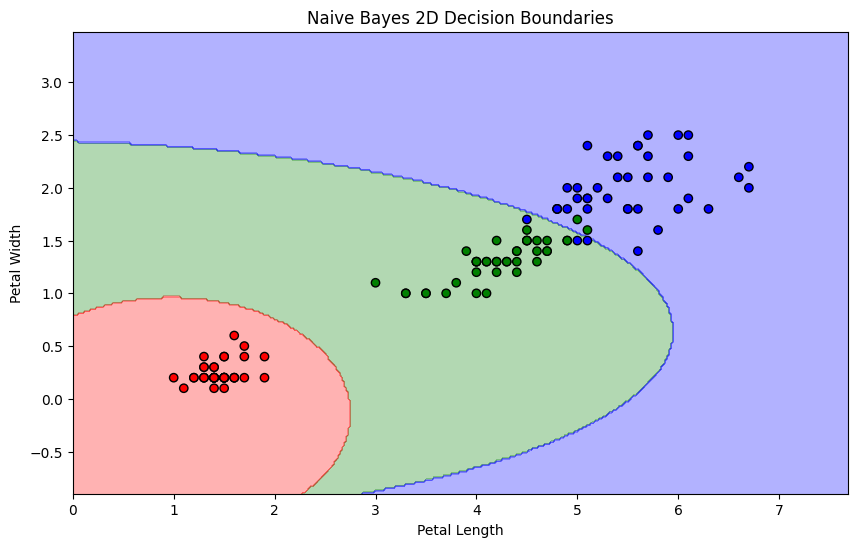

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# We'll use Petal Length and Petal Width for the 2D plot
X_2d = X_train[:, 2:4]
nb_2d = GaussianNBScratch()
nb_2d.fit(X_2d, y_train)

# Create a mesh grid
x_min, x_max = X_2d[:, 0].min() - 1, X_2d[:, 0].max() + 1
y_min, y_max = X_2d[:, 1].min() - 1, X_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict over the mesh
Z = nb_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(('red', 'green', 'blue')))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, edgecolors='k', cmap=ListedColormap(('red', 'green', 'blue')))
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.title('Naive Bayes 2D Decision Boundaries')
plt.show()

2D Visualization

In [ ]:
import plotly.graph_objects as go

# We'll visualize the "Bell Curves" for two features
# Features: Petal Length (x) and Petal Width (y)
x_rng = np.linspace(0, 8, 50)
y_rng = np.linspace(0, 3, 50)
xx, yy = np.meshgrid(x_rng, y_rng)

fig = go.Figure()

colors = ['red', 'green', 'blue']

for i, c_name in enumerate(iris.target_names):
    # Get mean and var for Petal Length (idx 2) and Petal Width (idx 3)
    mean_x, mean_y = nb.parameters[i]["mean"][2], nb.parameters[i]["mean"][3]
    var_x, var_y = nb.parameters[i]["var"][2], nb.parameters[i]["var"][3]

    # Calculate 2D Gaussian Density
    # PDF = (1 / 2*pi*std_x*std_y) * exp(-0.5 * ((x-ux)^2/vx + (y-uy)^2/vy))
    term1 = 1 / (2 * np.pi * np.sqrt(var_x * var_y))
    term2 = np.exp(-0.5 * (((xx - mean_x)**2 / var_x) + ((yy - mean_y)**2 / var_y)))
    zz = term1 * term2

    # Add surface for each class
    fig.add_trace(go.Surface(x=x_rng, y=y_rng, z=zz,
                             name=c_name, colorscale=[[0, colors[i]], [1, colors[i]]],
                             opacity=0.6, showscale=False))

fig.update_layout(title='3D Gaussian Density Clouds (Naive Bayes Likelihood)',
                  scene=dict(xaxis_title='Petal Length',
                             yaxis_title='Petal Width',
                             zaxis_title='Density'))
fig.show()

3D Visualization

*In Naive Bayes, we shifted from the "line-drawing" approach of regression models to a probabilistic approach based on Bayes' Theorem.The core of this model is the calculation of Likelihoods. Instead of finding weights ($w$), we analyzed our training data to build a Gaussian (Normal) Distribution—a bell curve—for every feature in every class. This allows the model to act like a statistical map: when a new data point arrives, the model doesn't ask "which side of the line is this on?" but rather, "under which class's bell curves is this point most probable?"We call it "Naive" because we make the simplifying assumption that every feature is independent. For example, the model assumes that the length of a petal has nothing to do with its width. Even though this assumption is technically "wrong" in nature, it makes the math incredibly efficient. Instead of performing expensive iterative calculations like Gradient Descent, we simply calculate the Mean and Variance once.Our 3D visualization perfectly captures this: we created Probability Density Clouds (the mountains) for each Iris species. The model's final decision is simply a "King of the Hill" contest—the class whose mountain is tallest at the input's coordinates wins the prediction. It is a fast, robust, and highly interpretable way to handle classification by mapping the statistical "territory" of your data.*